In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from worldcup.tournament import load_teams, get_groups, get_group_matches
from worldcup.simulator import GroupStageSimulator
from worldcup.algorithms.poisson import PoissonGoalModel, _poisson_pmf
from worldcup.algorithms.nathan_rating import NathanRatingModel

sns.set_theme(style='whitegrid', palette='muted')

# ── Configure model here ──────────────────────────────────────────────────────
rating_model = NathanRatingModel(fifa_power=0.5, w_fifa=0.5, w_equality=0.5)
predictor = PoissonGoalModel(rating_model, base_lambda=1.3, alpha=0.3, max_ratio=10.0)
N_SIMULATIONS = 20_000
SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

teams = load_teams()
groups = get_groups(teams)
flag_map  = {t.name: t.flag  for t in teams}
group_map = {t.name: t.group for t in teams}

# Nathan model

## Algorithm

Nathan combines two rankings into a single team strength score:

1. **FIFA ranking** — the official ranking at tournament start (lower = stronger)
2. **LGBT Equality Index** ([Equaldex](https://www.equaldex.com/equality-index), 0–100) — **inverted**: a lower equality score contributes a *higher* rating

The model tests the hypothesis: *do countries with worse LGBT equality perform better at football?*

### Rating formula

$$\text{rating} = w_f \cdot \frac{1}{\text{rank}^{p}} + w_e \cdot \frac{100 - \text{equality}}{100}$$

| Parameter | Value | Role |
|---|---|---|
| $p$ | 0.5 | Power transform on FIFA rank (smooths gap at the top) |
| $w_f$ | 0.5 | Weight on FIFA component |
| $w_e$ | 0.5 | Weight on inverted equality component |

The rating feeds into the same Poisson goal model as `poisson_fifa`:
$$\lambda_h = \lambda_0 \cdot \text{ratio}^{\alpha}, \qquad \lambda_a = \frac{\lambda_0}{\text{ratio}^{\alpha}}$$
with $\lambda_0 = 1.3$, $\alpha = 0.3$, max ratio cap = 10.

### Component breakdown — all WC teams

In [2]:
rows = []
for t in sorted(teams, key=lambda t: rating_model.rate(t), reverse=True):
    fifa_rank, equality = rating_model._rankings[t.name]
    fifa_score   = 1.0 / (fifa_rank ** rating_model.fifa_power)
    eq_score     = (100.0 - equality) / 100.0
    nathan_score = rating_model.rate(t)
    rows.append({
        'Team':          f'{flag_map[t.name]} {t.name}',
        'FIFA rank':     fifa_rank,
        'Equality':      int(equality),
        'FIFA score':    round(fifa_score, 4),
        'Inv. equality': round(eq_score, 4),
        'Nathan rating': round(nathan_score, 4),
    })

breakdown = pd.DataFrame(rows)
breakdown.style \
    .hide(axis='index') \
    .background_gradient(subset='Nathan rating', cmap='RdYlGn', vmin=0, vmax=1) \
    .background_gradient(subset='Equality',      cmap='RdYlGn', vmin=0, vmax=100) \
    .background_gradient(subset='FIFA rank',     cmap='RdYlGn_r', vmin=1, vmax=92)

Team,FIFA rank,Equality,FIFA score,Inv. equality,Nathan rating
🇫🇷 France,1,74,1.000000,0.260000,0.630000
🇸🇳 Senegal,14,4,0.267300,0.960000,0.613600
🇲🇦 Morocco,8,13,0.353600,0.870000,0.611800
🇮🇷 Iran,21,5,0.218200,0.950000,0.584100
🇪🇬 Egypt,29,10,0.185700,0.900000,0.542800
🇩🇿 Algeria,28,13,0.189000,0.870000,0.529500
🇶🇦 Qatar,55,8,0.134800,0.920000,0.527400
🇹🇳 Tunisia,44,14,0.150800,0.860000,0.505400
🇮🇶 Iraq,57,13,0.132500,0.870000,0.501200
🇸🇦 Saudi Arabia,61,13,0.128000,0.870000,0.499000


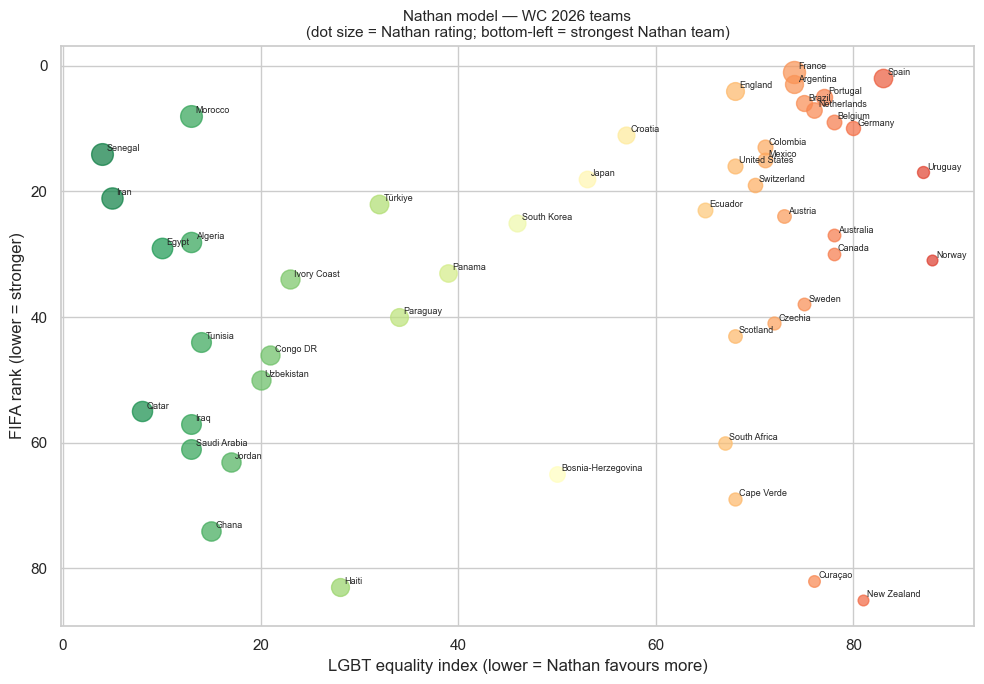

In [3]:
# Scatter: FIFA rank vs equality score, sized by Nathan rating
fig, ax = plt.subplots(figsize=(10, 7))

for t in teams:
    fifa_rank, equality = rating_model._rankings[t.name]
    nathan = rating_model.rate(t)
    ax.scatter(equality, fifa_rank, s=nathan * 400, alpha=0.7,
               color=plt.cm.RdYlGn_r(equality / 100))
    ax.annotate(t.name, (equality, fifa_rank), fontsize=6.5,
                xytext=(3, 2), textcoords='offset points')

ax.invert_yaxis()
ax.set_xlabel('LGBT equality index (lower = Nathan favours more)')
ax.set_ylabel('FIFA rank (lower = stronger)')
ax.set_title('Nathan model — WC 2026 teams\n(dot size = Nathan rating; bottom-left = strongest Nathan team)', fontsize=11)
plt.tight_layout()
plt.show()

### Example prediction — Spain vs Iran

Spain: Nathan rating = 0.4386  (FIFA 2, equality 83)
Iran: Nathan rating = 0.5841  (FIFA 21, equality 5)
λ_home = 1.193,  λ_away = 1.417


Outcome,Probability
🇪🇸 Spain win,31.7%
Draw,26.1%
🇮🇷 Iran win,42.2%


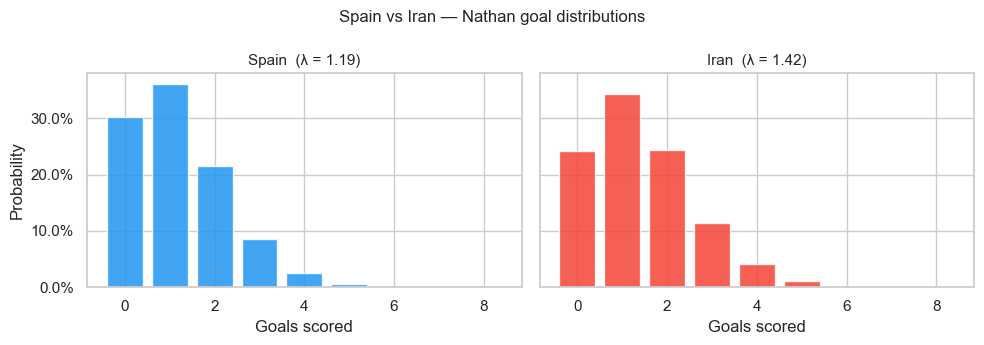

In [4]:
example_home = next(t for t in teams if t.name == 'Spain')
example_away = next(t for t in teams if t.name == 'Iran')

λ_h, λ_a = predictor.lambdas(example_home, example_away)
p_home, p_draw, p_away = predictor.predict(example_home, example_away)

r_home, r_away = rating_model.rate(example_home), rating_model.rate(example_away)
print(f'{example_home.name}: Nathan rating = {r_home:.4f}  (FIFA {rating_model._rankings[example_home.name][0]}, equality {rating_model._rankings[example_home.name][1]:.0f})')
print(f'{example_away.name}: Nathan rating = {r_away:.4f}  (FIFA {rating_model._rankings[example_away.name][0]}, equality {rating_model._rankings[example_away.name][1]:.0f})')
print(f'λ_home = {λ_h:.3f},  λ_away = {λ_a:.3f}')

example_df = pd.DataFrame([
    {'Outcome': f'{example_home.flag} {example_home.name} win', 'Probability': p_home},
    {'Outcome': 'Draw',                                          'Probability': p_draw},
    {'Outcome': f'{example_away.flag} {example_away.name} win', 'Probability': p_away},
])
display(example_df.style.hide(axis='index')
        .format({'Probability': '{:.1%}'})
        .bar(subset='Probability', color='#90CAF9', vmin=0, vmax=1))

# Goal distributions
max_g = 8
goals = np.arange(0, max_g + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].bar(goals, [_poisson_pmf(g, λ_h) for g in goals], color='#2196F3', alpha=0.85)
axes[0].set_title(f'{example_home.name}  (λ = {λ_h:.2f})', fontsize=11)
axes[0].set_xlabel('Goals scored'); axes[0].set_ylabel('Probability')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[1].bar(goals, [_poisson_pmf(g, λ_a) for g in goals], color='#F44336', alpha=0.85)
axes[1].set_title(f'{example_away.name}  (λ = {λ_a:.2f})', fontsize=11)
axes[1].set_xlabel('Goals scored')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
fig.suptitle(f'{example_home.name} vs {example_away.name} — Nathan goal distributions', fontsize=12)
plt.tight_layout(); plt.show()

---

## Group stage qualification probabilities

In [5]:
sim = GroupStageSimulator(predictor, n=N_SIMULATIONS, seed=SEED)
results = sim.run(groups)
df = results.to_dataframe()

df['flag']  = df['team'].map(flag_map)
df['group'] = df['team'].map(group_map)
df['Team']  = df['flag'] + ' ' + df['team']

# Add equality index for context
df['equality'] = df['team'].map(lambda n: int(rating_model._rankings[n][1]))

qual_table = df[['group', 'Team', 'equality', 'p_qualify', 'p_group_winner', 'p_runner_up', 'p_best_third', 'p_eliminated']].copy()
qual_table.columns = ['Group', 'Team', 'Equality', 'Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']

qual_table.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']}) \
    .background_gradient(subset='Qualify',    cmap='RdYlGn',   vmin=0, vmax=1) \
    .background_gradient(subset='Eliminated', cmap='RdYlGn_r', vmin=0, vmax=1) \
    .background_gradient(subset='Equality',   cmap='RdYlGn',   vmin=0, vmax=100)

Group,Team,Equality,Qualify,1st,2nd,Best 3rd,Eliminated
G,🇮🇷 Iran,5,85.1%,39.5%,30.8%,14.8%,14.9%
E,🇨🇮 Ivory Coast,23,84.5%,43.1%,27.8%,13.7%,15.5%
B,🇶🇦 Qatar,8,84.4%,43.8%,27.1%,13.4%,15.7%
H,🇸🇦 Saudi Arabia,13,83.5%,40.1%,29.0%,14.5%,16.5%
G,🇪🇬 Egypt,10,83.5%,37.9%,31.0%,14.6%,16.5%
C,🇲🇦 Morocco,13,83.3%,42.2%,27.3%,13.8%,16.7%
I,🇫🇷 France,74,82.6%,35.9%,29.4%,17.3%,17.4%
F,🇹🇳 Tunisia,14,82.1%,39.8%,27.9%,14.5%,17.9%
I,🇸🇳 Senegal,4,81.8%,33.8%,30.7%,17.3%,18.1%
H,🇪🇸 Spain,83,79.3%,34.7%,29.7%,14.9%,20.7%


---

## Match predictions

In [6]:
match_rows = []
for group_name, group_teams in sorted(groups.items()):
    for home, away in get_group_matches(group_teams):
        λ_h, λ_a = predictor.lambdas(home, away)
        p_hw, p_d, p_aw = predictor.predict(home, away)
        match_rows.append({
            'Group':      group_name,
            'Home':       f'{home.flag} {home.name}',
            'Away':       f'{away.flag} {away.name}',
            'λ home':     round(λ_h, 3),
            'λ away':     round(λ_a, 3),
            'Home win %': p_hw,
            'Draw %':     p_d,
            'Away win %': p_aw,
        })

matches_df = pd.DataFrame(match_rows)
matches_df.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Home win %', 'Draw %', 'Away win %']}) \
    .background_gradient(subset='Home win %', cmap='Blues',  vmin=0, vmax=1) \
    .background_gradient(subset='Away win %', cmap='Reds',   vmin=0, vmax=1) \
    .background_gradient(subset='Draw %',     cmap='Greens', vmin=0, vmax=1)

Group,Home,Away,λ home,λ away,Home win %,Draw %,Away win %
A,🇲🇽 Mexico,🇿🇦 South Africa,1.371000,1.233000,40.1%,26.3%,33.6%
A,🇲🇽 Mexico,🇰🇷 South Korea,1.188000,1.422000,31.5%,26.1%,42.4%
A,🇲🇽 Mexico,🇨🇿 Czechia,1.392000,1.214000,41.1%,26.2%,32.7%
A,🇿🇦 South Africa,🇰🇷 South Korea,1.127000,1.500000,28.5%,25.7%,45.8%
A,🇿🇦 South Africa,🇨🇿 Czechia,1.320000,1.280000,37.7%,26.4%,35.9%
A,🇰🇷 South Korea,🇨🇿 Czechia,1.523000,1.109000,46.8%,25.5%,27.7%
B,🇨🇦 Canada,🇧🇦 Bosnia-Herzegovina,1.140000,1.483000,29.1%,25.8%,45.1%
B,🇨🇦 Canada,🇶🇦 Qatar,0.974000,1.736000,21.1%,23.7%,55.3%
B,🇨🇦 Canada,🇨🇭 Switzerland,1.197000,1.411000,31.9%,26.2%,41.9%
B,🇧🇦 Bosnia-Herzegovina,🇶🇦 Qatar,1.111000,1.522000,27.7%,25.6%,46.7%
